**Name - Arihant Gupta**
<br>
**Enrolment - E23CSEU0055**
<br>
**Batch - EB_02**
<br>
**Date - 23 Sep 2025**
<br>
**Lab - 15**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

1.	Load the California Housing dataset from sklearn.datasets into your Python environment using the fetch_california_housing() function and convert the dataset into a Pandas DataFrame.

In [16]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

sns.set_style("whitegrid")


2.	Perform exploratory data analysis (EDA) by visualizing the distribution of key variables

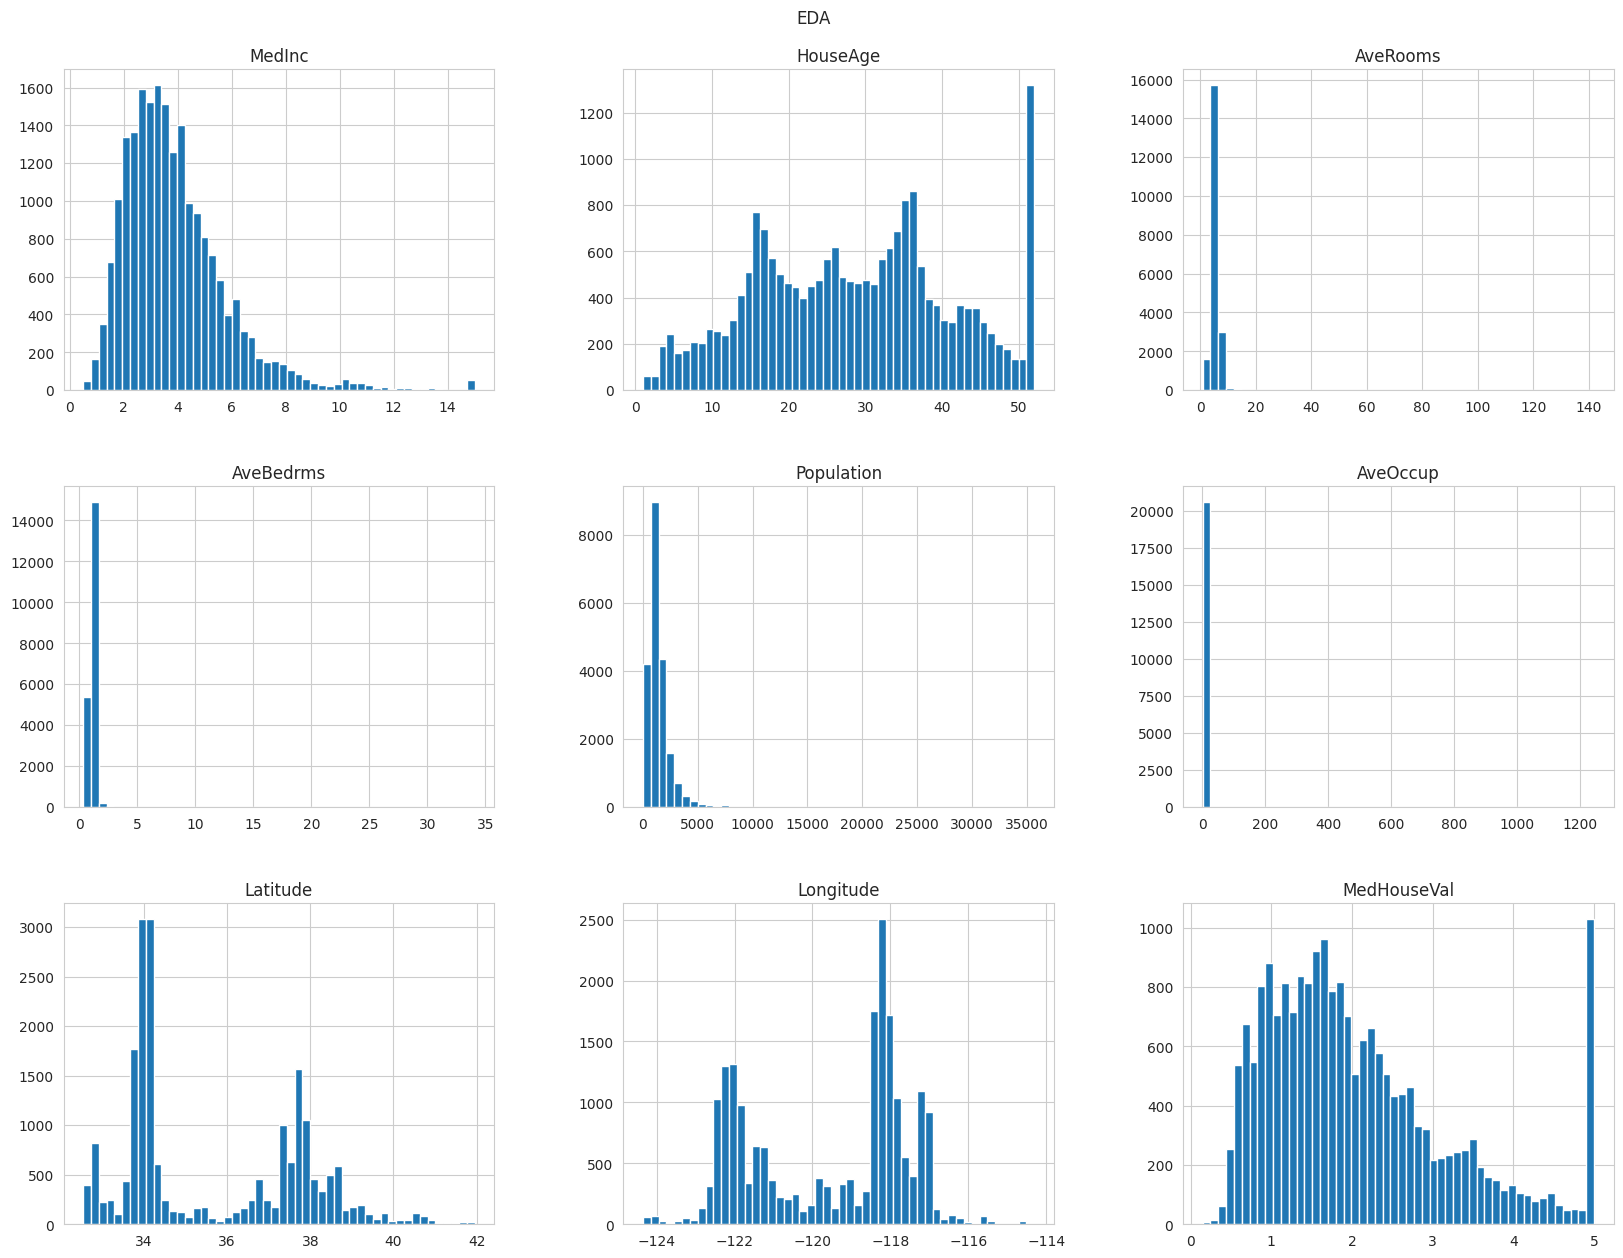

In [17]:
df.hist(bins=50, figsize=(20,15))
plt.suptitle("EDA", y=0.92)
plt.show()

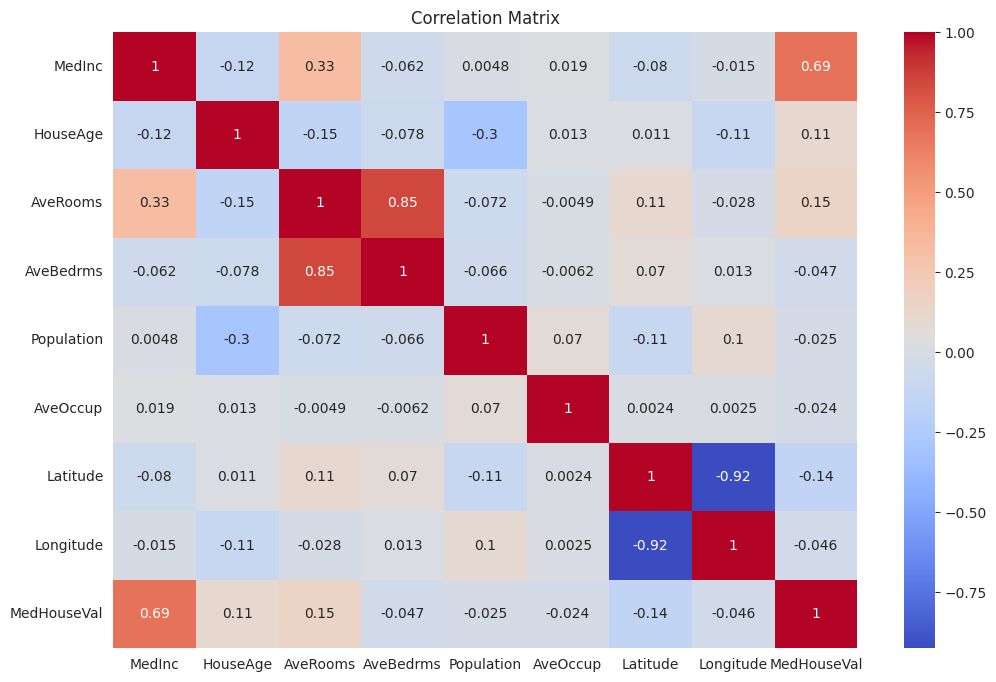

In [18]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

3.	On the available features, perform preprocessing, select only the relevant numerical attributes that are expected to influence the housing price prediction (e.g., average number of rooms, median income).

In [27]:
features = ['MedInc', 'HouseAge', 'AveBedrms']
X = df[features]
y = df['MedHouseVal']

4.	Divide the dataset into training and testing subsets using train_test_split() from sklearn.model_selection, typically with an 80-20 split for training and testing respectively.

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_processed = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y.values, test_size=0.2, random_state=42
)

5.	Perform each of the optimization algorithms on the training dataset one by one.

In [29]:
def batch_gradient_descent(X, y, learning_rate=0.01, epochs=100):
    n_samples, n_features = X.shape
    weights = np.random.randn(n_features)
    loss_history = []

    for epoch in range(epochs):
        y_pred = X.dot(weights)
        error = y_pred - y
        gradient = (2/n_samples) * X.T.dot(error)
        weights -= learning_rate * gradient
        loss = mse_loss(y, y_pred)
        loss_history.append(loss)
    return loss_history

In [30]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=100):
    n_samples, n_features = X.shape
    weights = np.random.randn(n_features)
    loss_history = []

    for epoch in range(epochs):
        # Shuffle data for each epoch
        shuffled_indices = np.random.permutation(n_samples)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(n_samples):
            # Process one sample at a time
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            # Prediction for one sample
            y_pred = xi.dot(weights)
            # Calculate error
            error = y_pred - yi
            # Calculate gradient for one sample
            gradient = 2 * xi.T.dot(error)
            # Update weights
            weights -= learning_rate * gradient

        # Calculate loss for the entire training set at the end of the epoch
        total_epoch_pred = X.dot(weights)
        loss = mse_loss(y, total_epoch_pred)
        loss_history.append(loss)
    return loss_history

In [31]:
def mini_batch_gradient_descent(X, y, learning_rate=0.01, epochs=100, batch_size=32):
    n_samples, n_features = X.shape
    weights = np.random.randn(n_features)
    loss_history = []

    for epoch in range(epochs):
        # Shuffle data for each epoch
        shuffled_indices = np.random.permutation(n_samples)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(0, n_samples, batch_size):
            # Process one mini-batch at a time
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]
            # Prediction for the mini-batch
            y_pred = xi.dot(weights)
            # Calculate error
            error = y_pred - yi
            # Calculate gradient for the mini-batch
            gradient = (2/batch_size) * xi.T.dot(error)
            # Update weights
            weights -= learning_rate * gradient

        # Calculate loss for the entire training set at the end of the epoch
        total_epoch_pred = X.dot(weights)
        loss = mse_loss(y, total_epoch_pred)
        loss_history.append(loss)
    return loss_history

6.	Use MSE loss as the cost function. Store the losses for each epoch in a list data structure

In [32]:
epochs = 100
learning_rate = 0.01

bgd_losses = batch_gradient_descent(X_train, y_train, learning_rate, epochs)
sgd_losses = stochastic_gradient_descent(X_train, y_train, learning_rate, epochs)
mbgd_losses = mini_batch_gradient_descent(X_train, y_train, learning_rate, epochs)

7.	Draw a scatter plot using the stored losses for each optimizer and mention your inference from the three models as well suggest which optimizer works the best w.r.t fastest convergence.

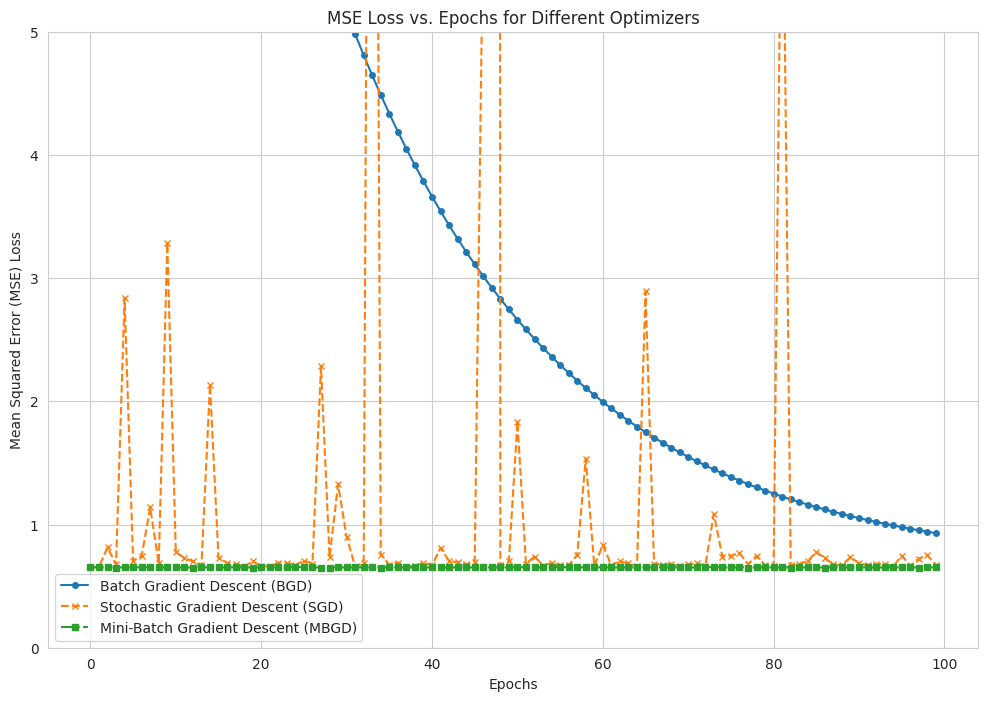

In [33]:
plt.figure(figsize=(12, 8))
plt.plot(range(epochs), bgd_losses, label='Batch Gradient Descent (BGD)', marker='o', linestyle='-', markersize=4)
plt.plot(range(epochs), sgd_losses, label='Stochastic Gradient Descent (SGD)', marker='x', linestyle='--', markersize=4)
plt.plot(range(epochs), mbgd_losses, label='Mini-Batch Gradient Descent (MBGD)', marker='s', linestyle='-.', markersize=4)

plt.title('MSE Loss vs. Epochs for Different Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE) Loss')
plt.legend()
plt.grid(True)
plt.ylim(0, 5)
plt.show()
